In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pysuto.util import get_path

figp = r'/mnt/nfs_fineprint/tmp/PYSUT/pySUTO/figs/ex'


In [10]:
sp = r'/mnt/nfs_fineprint/tmp/PYSUT/pySUTO/data/proc/datafeed/icsg_clean/icsg_stocks.csv'
s = pd.read_csv(sp)

In [11]:
s


,Type,Region,Year,Value,Unit,Stock_type,Year_loaded_from_file
0,Producers,Zambia,1998,15.900000,kt,PMC,2005
1,Consumers,Italy,1997,23.200000,kt,PMC,2005
2,Producers,Japan,1997,79.600000,kt,PMC,2005
3,Merchants,Japan,1997,23.400000,kt,PMC,2005
4,Consumers,Japan,1997,44.200000,kt,PMC,2005
...,...,...,...,...,...,...,...
1110,Producers,Canada,2023,7.893032,kt,PMC,2025
1111,Producers,Chile,2023,559.192085,kt,PMC,2025
1112,Total,China,2023,80.000000,kt,PMC,2025
1113,Producers,Finland,2023,1.200000,kt,PMC,2025


In [12]:
s[(s.Stock_type == 'Exchanges')].sort_values('Year')

,Type,Region,Year,Value,Unit,Stock_type,Year_loaded_from_file
154,COMEX,United States,1995,21.740,kt,Exchanges,2005
169,LME,United States,1995,68.200,kt,Exchanges,2005
168,LME,United Kingdom,1995,6.700,kt,Exchanges,2005
167,LME,Sweden,1995,4.200,kt,Exchanges,2005
165,LME,Singapore,1995,51.700,kt,Exchanges,2005
...,...,...,...,...,...,...,...
896,LME,United Arab Emirates,2024,0.000,kt,Exchanges,2025
897,LME,United Kingdom,2024,0.000,kt,Exchanges,2025
898,LME,United States,2024,0.525,kt,Exchanges,2025
899,COMEX,United States,2024,84.706,kt,Exchanges,2025


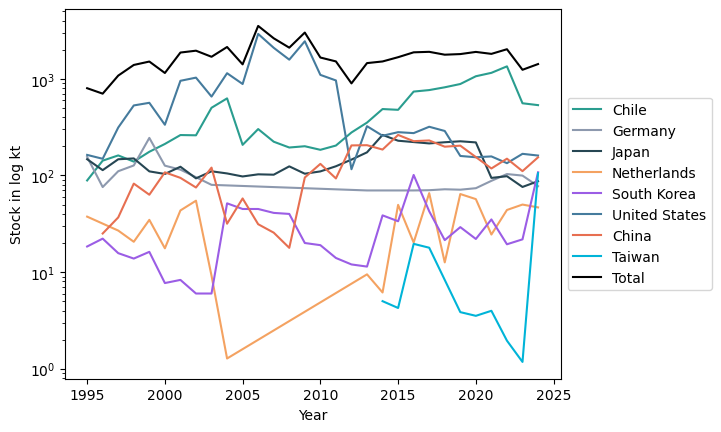

In [13]:
c_select = ['Chile', 'Japan', 
            'China', 'United States', 'Netherlands',
            'Germany', 'South Korea', 'Taiwan']

colors = {
    'Chile': '#2A9D8F',        # teal
    'Japan': '#264653',        # deep blue
    'China': '#E76F51',        # muted red
    'United States': '#457B9D',# steel blue
    'Netherlands': '#F4A261',  # soft orange
    'Germany': '#8D99AE',      # cool gray blue
    'South Korea': '#9B5DE5',  # soft purple
    'Taiwan': '#00B4D8',       # cyan
    'Total': '#D9D9D9' # light gray
}



data = s[s['Region'].isin(c_select)].groupby(['Year', 'Region'])['Value'].sum().reset_index()
sns.lineplot(data =data[data.Value >1],
x='Year', 
y= 'Value',
hue='Region', 
palette=colors)
plt.yscale('log')
#leggend to the rgiht out of plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Stock in log kt')

# plot also total copper in black
total = s.groupby('Year')['Value'].sum().reset_index()
sns.lineplot(data =total[total.Value >1],
x='Year',
y= 'Value',
color='black',
label='Total')
plt.yscale('log')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(os.path.join(figp, 'stock abs.jpg'), bbox_inches='tight')

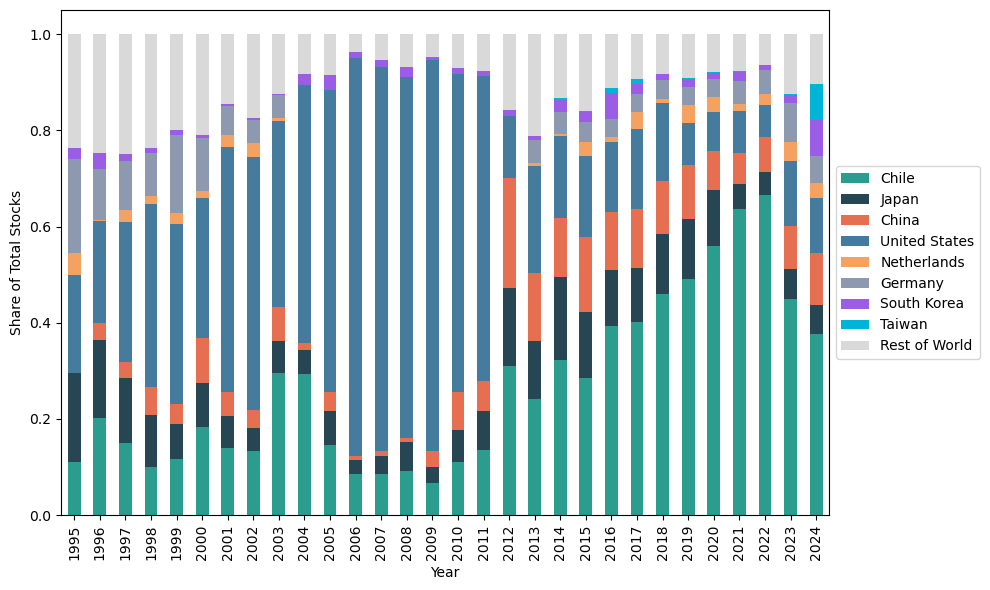

In [14]:


# countries to display individually
c_select = [
    'Chile','Japan','China','United States',
    'Netherlands','Germany','South Korea', 'Taiwan'
]
colors = {
    'Chile': '#2A9D8F',        # teal
    'Japan': '#264653',        # deep blue
    'China': '#E76F51',        # muted red
    'United States': '#457B9D',# steel blue
    'Netherlands': '#F4A261',  # soft orange
    'Germany': '#8D99AE',      # cool gray blue
    'South Korea': '#9B5DE5',  # soft purple
    'Taiwan': '#00B4D8',       # cyan
    'Rest of World': '#D9D9D9' # light gray
}


# -------------------------------------------------
# 1. Aggregate country values
# -------------------------------------------------

data = s.groupby(['Year','Region'])['Value'].sum().reset_index()

# total per year
total = data.groupby('Year')['Value'].sum().reset_index().rename(columns={'Value':'Total'})

# merge totals
data = data.merge(total, on='Year')

# compute share
data['Share'] = data['Value'] / data['Total']

# -------------------------------------------------
# 2. Label Rest of World
# -------------------------------------------------

data['Region_plot'] = data['Region'].where(
    data['Region'].isin(c_select),
    'Rest of World'
)

data = data.groupby(['Year','Region_plot'])['Share'].sum().reset_index()

# -------------------------------------------------
# 3. Pivot for stacked bars
# -------------------------------------------------

df_plot = data.pivot(index='Year', columns='Region_plot', values='Share').fillna(0)

# ensure column order
order = c_select + ['Rest of World']
df_plot = df_plot[[c for c in order if c in df_plot.columns]]

# -------------------------------------------------
# 4. Plot stacked bar chart
# -------------------------------------------------

ax = df_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6), 
    color=[colors.get(c, '#D9D9D9') for c in df_plot.columns],
    edgecolor='None'
)

ax.set_ylabel('Share of Total Stocks')
ax.set_xlabel('Year')

plt.legend(
    loc='center left',
    bbox_to_anchor=(1,0.5)
)

# store fig
p = os.path.join(figp, 'stock_rel.jpg')

plt.savefig(p, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()




In [15]:
top30_per_type = (
    s.sort_values('Value', ascending=False)
      .groupby(['Type', 'Year'])
      .head(10)
)

# Step 2: get unique regions from these selections
unique_regions = top30_per_type['Region'].unique()

# Optional: convert to list
unique_regions_list = list(unique_regions)

print(unique_regions_list)

['United States', 'Chile', 'China', 'Germany', 'Japan', 'Taiwan', 'Singapore', 'Malaysia', 'South Korea', 'Spain', 'Iran', 'Belgium', 'Netherlands', 'United Arab Emirates', 'France', 'Brazil', 'United Kingdom', 'Sweden', 'Italy', 'Poland', 'Zambia', 'Canada', 'Peru', 'South Africa', 'Australia', 'Philippines', 'Scandinavia', 'India', 'Bulgaria', 'Slovakia', 'Greece']
